In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### plot setting

In [2]:
# sns.set(context='paper')
# plt.style.use('default')

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'

In [3]:
df_clean = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')

if 'bound' not in df_clean.columns:
    # create bound col, mapping condition to .25, .5, .75
    condition_to_bound = {'curv_comp': 0.25, 'baseline': 0.5, 'flat_comp': 0.75}
    df_clean['bound'] = df_clean['condition'].map(condition_to_bound)

if 'div_true' not in df_clean.columns:
    # create div_true col, mapping condition to -.2, 0, .2
    condition_to_div_true = {'curv_comp': -0.2, 'baseline': 0, 'flat_comp': 0.2}
    df_clean['div_true'] = df_clean['condition'].map(condition_to_div_true)

# rename cols: chosen_pos->resp; stim_aligned_to_div->stim_aligned; resp_aligned_to_div->resp_aligned; div_pos->div; target_pos->target
df_clean.rename(columns={'chosen_pos': 'resp', 'stim_aligned_to_div': 'stim_aligned', 'resp_aligned_to_div': 'resp_aligned', 'div_pos': 'div', 'target_pos': 'target'}, inplace=True)

df_view = df_clean.drop_duplicates(subset=['condition', 'bound', 'div'])
df_view[['subj', 'condition', 'bound', 'div_true', 'div', 'stim_pos', 'stim_aligned', 'resp', 'resp_aligned']].head()

,subj,condition,bound,div_true,div,stim_pos,stim_aligned,resp,resp_aligned
0,9,baseline,0.50,0.0,0.0,0.02,0.02,0.044,-0.044
8,9,curv_comp,0.25,-0.2,-0.2,0.14,0.34,-0.092,0.108
9,9,curv_comp,0.25,-0.2,0.2,-0.10,0.10,0.156,0.044
16,9,flat_comp,0.75,0.2,0.2,-0.14,-0.34,0.128,-0.072
17,9,flat_comp,0.75,0.2,-0.2,0.22,0.02,-0.148,-0.052


### setup

In [4]:
patients = df_clean['subj'].unique().tolist()
n_pts = len(patients)
print(f'{n_pts} patients: {patients}')

bounds = df_clean['bound'].unique().tolist()
print(f'bounds/contexts: {bounds}')

df_curv = df_clean[df_clean['condition'] == 'curv_comp'].copy()
df_base = df_clean[df_clean['condition'] == 'baseline'].copy()
df_flat = df_clean[df_clean['condition'] == 'flat_comp'].copy()

print(len(df_curv), len(df_base), len(df_flat))

6 patients: [9, 11, 12, 18, 21, 22]
bounds/contexts: [0.5, 0.25, 0.75]
480 480 480


In [5]:
# choose what df
def get_df(df_name):
    if df_name == 'base':
        return df_name, df_base
    elif df_name == 'curv':
        return df_name, df_curv
    elif df_name == 'flat':
        return df_name, df_flat

### timing checks

In [6]:
# # choose what youre plotting
# ptID = 9
# df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
# # df_analysis = df_clean.copy()
# print(f'len(df): {len(df_analysis)}')

# # create column for each phases's duration
# expt_phases = ['baseline', 'stim', 'delay', 'task', 'anticipation', 'feedback']
# for phase in expt_phases:
#     df_analysis[f'{phase}_dur'] = df_analysis[f'{phase}.stopped'] - df_analysis[f'{phase}.started']

# # sid, check if these are needed replacements
# df_analysis['stim_dur'] = df_analysis['stim.stopped'] - df_analysis['target_stim.started']
# df_analysis['feedback_dur'] = df_analysis['feedback.stopped'] - df_analysis['no_resp_text.started']

# fig, axs = plt.subplots(2, 3, figsize=(15, 4))
# axs, ax = axs.flatten(), 0

# for expt_phase in expt_phases:

#     sns.histplot(df_analysis[f'{expt_phase}_dur'], bins=20, kde=True, ax=axs[ax])
#     axs[ax].set(title=expt_phase, xlabel='', ylabel='Count')
#     ax += 1

# plt.suptitle(f'Task Durations', fontsize=16)
# plt.tight_layout()
# plt.show()

### error trials

In [7]:
# choose what youre plotting
ptID = 9
df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
df_analysis = df_clean.copy()
print(f'len(df): {len(df_analysis)}')

num_incomplete = df_analysis['incomplete'].sum()
num_invalid = df_analysis['invalid'].sum()
num_incorrect = df_analysis['incorrect'].sum()
print(f'\
incomplete: {num_incomplete} ({num_incomplete / 240 * 100:.2f}%),\
 invalid: {num_invalid} ({num_invalid / 240 * 100:.2f}%),\
 incorrect: {num_incorrect} ({num_incorrect / 240 * 100:.2f}%)')

# proportion correct
prop_correct = df_analysis['correct'].mean()
print(f'Proportion correct: {prop_correct:.2f}')

# pearson and spearman correlations between stim_pos and resp_aligned
pearson_corr = df_analysis['stim_pos'].corr(df_analysis['resp_aligned'], method='pearson')
spearman_corr = df_analysis['stim_pos'].corr(df_analysis['resp_aligned'], method='spearman')
print(f'Pearson correlation: {pearson_corr:.2f}')
print(f'Spearman correlation: {spearman_corr:.2f}')

# ensure this is the same
pearson_corr = df_analysis['target'].corr(df_analysis['resp'], method='pearson')
spearman_corr = df_analysis['target'].corr(df_analysis['resp'], method='spearman')


len(df): 1440
incomplete: 36 (15.00%), invalid: 30 (12.50%), incorrect: 248 (103.33%)
Proportion correct: 0.79
Pearson correlation: 0.38
Spearman correlation: 0.50


### plot setup

In [8]:
norm_ticks, norm_ticklabels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)

### response distribution

In [9]:

# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# ba_bins = np.linspace(-.4, .4, 21)
# bar_centers = np.linspace(-.38, .38, 20)

# for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered

#     df_cond = df_analysis[df_analysis['condition'] == cond].copy()

#     # true stim distribution per subj (stim_pos is already in -.4 to .4 space)
#     stim_cts = []
#     for subj, subj_df in df_cond.groupby('subj'):
#         counts, _ = np.histogram(subj_df['stim_pos'], bins=ba_bins)
#         stim_cts.append(counts)
#     stim_cts = np.array(stim_cts)
#     mean_stim_cts = stim_cts.mean(axis=0)

#     # response distribution per subj
#     resp_cts = []
#     for subj, subj_df in df_cond.groupby('subj'):
#         counts, _ = np.histogram(subj_df['chosen_pos_aligned'], bins=ba_bins)
#         resp_cts.append(counts)
#     resp_cts = np.array(resp_cts)
#     mean_resp_cts = resp_cts.mean(axis=0)
#     sem_resp_cts = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])

#     # plot
#     axs[ax].bar(bar_centers, mean_stim_cts, width=.04, color='green', alpha=0.7, label='stim')
#     axs[ax].bar(bar_centers, mean_resp_cts, width=.04, color='deepskyblue',
#                 yerr=sem_resp_cts, capsize=3, label='response', alpha=0.6)

#     axs[ax].set(xlabel='position', ylabel='count', xlim=(-.4, .4), ylim=(0,20),
#                 xticks=norm_ticks, xticklabels=norm_ticklabels)
#     # boundary
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     axs[ax].legend(fontsize=8)
#     ax += 1

# plt.suptitle(f'Patients (n={df_analysis["subj"].nunique()})', fontsize=16)
# plt.tight_layout()
# plt.show()


## stim vs resp

### raw

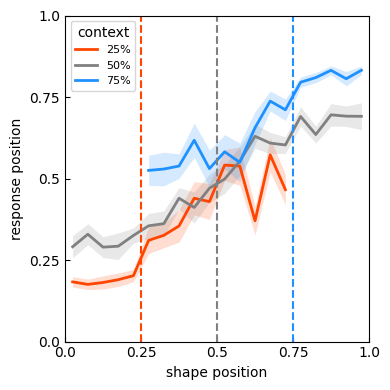

In [10]:
# plot stim vs resp, colored by condition (mean ± SEM)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    # Compute mean and SEM for each stim_pos
    grouped = df_cond.groupby('stim_pos')['chosen_pos_aligned']
    mean_resp = grouped.mean().sort_index()
    sem_resp = grouped.sem().sort_index()
    x = mean_resp.index.values
    y = mean_resp.values
    yerr = sem_resp.values
    # Plot mean line
    ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
    # Plot SEM band
    ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# add identity line
# ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
ax.axvline(-0.2, color='orangered', linewidth=1.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=1.5, linestyle='--')
ax.axvline(0.2, color='dodgerblue', linewidth=1.5, linestyle='--')

ax.set(xlabel='shape position', ylabel='response position',
       xticks=norm_ticks, xticklabels=norm_ticklabels,
       yticks=norm_ticks, yticklabels=norm_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))
ax.tick_params(axis='both', direction='in')

ax.legend(fontsize=8, title='context')
plt.tight_layout()
plt.show()


### boundary-aligned

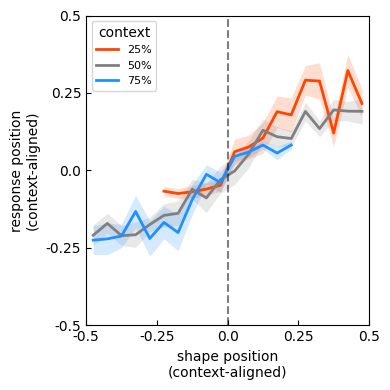

In [11]:
# plot stim vs resp, colored by condition (mean ± SEM)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    grouped = df_cond.groupby('stim_aligned')['resp_aligned']
    mean_resp = grouped.mean().sort_index()
    sem_resp = grouped.sem().sort_index()
    x = mean_resp.index.values
    y = mean_resp.values
    yerr = sem_resp.values
    ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
    ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ba_ticklabels = np.linspace(-.5, .5, 5)
ax.set(xlabel='shape position\n(context-aligned)', ylabel='response position\n(context-aligned)',
       xticks=norm_ticks, xticklabels=ba_ticklabels,
       yticks=norm_ticks, yticklabels=ba_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))
ax.tick_params(axis='both', direction='in')

ax.legend(fontsize=8, title='context')
plt.tight_layout()
plt.show()


### rank-aligned

In [12]:
# # plot stim vs resp, colored by condition (mean ± SEM)
# fig, ax = plt.subplots(1, 1, figsize=(4,4))
# colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
# cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

# for cond in ['curv_comp', 'baseline', 'flat_comp']:
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
#     grouped = df_cond.groupby('stim_ranks')['resp_ranks']
#     mean_resp = grouped.mean().sort_index()
#     sem_resp = grouped.sem().sort_index()
#     x = mean_resp.index.values
#     y = mean_resp.values
#     yerr = sem_resp.values
#     ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
#     ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# ax.axvline(40, color='black', linewidth=1.5, linestyle='--')
# ax.set(xlabel='stim rank', ylabel='resp rank')
# ax.legend(fontsize=8, title='context')
# plt.tight_layout()
# plt.show()


### visualizing reflection of compressed conditions

In [13]:
# # plot stim vs resp, colored by condition (mean ± SEM)
# fig, ax = plt.subplots(1, 1, figsize=(4,4))
# colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
# cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

# for cond in ['curv_comp', 'baseline', 'flat_comp']:
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
#     if cond == 'flat_comp':
#         df_cond['stim_aligned_to_div'] = -df_cond['stim_aligned_to_div']
#         df_cond['resp_aligned_to_div'] = -df_cond['resp_aligned_to_div']
#     grouped = df_cond.groupby('stim_aligned_to_div')['resp_aligned_to_div']
#     mean_resp = grouped.mean().sort_index()
#     sem_resp = grouped.sem().sort_index()
#     x = mean_resp.index.values
#     y = mean_resp.values
#     yerr = sem_resp.values
#     ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
#     ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# # add identity line
# # ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
# ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
# ax.set(xlabel='shape position\n(baseline-reflected)', ylabel='response position\n(baseline-reflected)',
#        xticks=norm_ticks, xticklabels=norm_ticklabels,
#        yticks=norm_ticks, yticklabels=norm_ticklabels,
#        xlim=(-.4, .4), ylim=(-.4, .4))

# ax.legend(fontsize=8, title='context')
# plt.tight_layout()
# plt.show()


### sigfic testing

In [14]:
# --- Context-shift alignment MSEs: within vs between ---
from itertools import combinations

all_within_MSEs = []  # per subjs
all_between_MSEs = []  # per subjs

for subj in patients:
    subjs_df = df_clean[df_clean['subj'] == subj]
    # Compute 3 within-context MSEs (stim_aligned vs resp_aligned for each context)
    subjs_within_MSEs = []
    for bound in bounds:
        context_df = subjs_df[subjs_df['bound'] == bound]
        mse = np.mean((context_df['stim_aligned'].values - context_df['resp_aligned'].values) ** 2)
        subjs_within_MSEs.append(mse)
    all_within_MSEs.append(np.mean(subjs_within_MSEs))

    # Compute between-context MSEs (pairwise resp_aligned between contexts)
    subj_between_MSEs = []
    for bound1, bound2 in combinations(bounds, 2):
        c1_df = subjs_df[subjs_df['bound'] == bound1]
        c2_df = subjs_df[subjs_df['bound'] == bound2]

        # retain resps only for overlapping stim_aligned vals between the two contexts
        common_stim_aligned = np.intersect1d(c1_df['stim_aligned'].values, c2_df['stim_aligned'].values)
        c1_overlap = c1_df[c1_df['stim_aligned'].isin(common_stim_aligned)].sort_values('stim_aligned')
        c2_overlap = c2_df[c2_df['stim_aligned'].isin(common_stim_aligned)].sort_values('stim_aligned')
        
        # avg over duplicated stim_aligned vals
        c1_mean = c1_overlap.groupby('stim_aligned')['resp_aligned'].mean()
        c2_mean = c2_overlap.groupby('stim_aligned')['resp_aligned'].mean()

        # Now align indices and compute MSE
        common_index = c1_mean.index.intersection(c2_mean.index)
        mse = np.mean((c1_mean.loc[common_index] - c2_mean.loc[common_index]) ** 2)

        subj_between_MSEs.append(mse)
    all_between_MSEs.append(np.mean(subj_between_MSEs))

all_within_MSEs = np.array(all_within_MSEs)
all_between_MSEs = np.array(all_between_MSEs)

print('Subjs\' within-context MSEs:', all_within_MSEs)
print('Subjs\' between-context MSEs:', all_between_MSEs)
print('Mean within:', all_within_MSEs.mean(), 'Mean between:', all_between_MSEs.mean())

Subjs' within-context MSEs: [0.0251236  0.02946387 0.03071533 0.02697    0.02823667 0.04253907]
Subjs' between-context MSEs: [0.00141782 0.01052222 0.02600437 0.00171084 0.00303089 0.0295916 ]
Mean within: 0.030508088888888885 Mean between: 0.01204629074074074


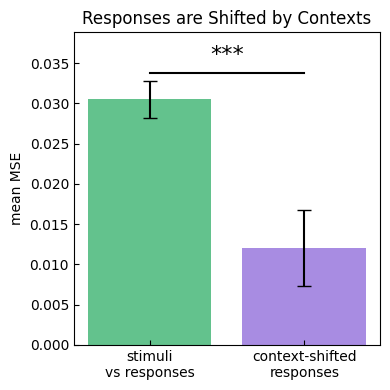

In [15]:
# --- Bar plot: Within vs Between context alignment MSEs ---
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
axs = [axs]  # flatten for consistent indexing
ax = 0

means = [all_within_MSEs.mean(), all_between_MSEs.mean()]
sems = [all_within_MSEs.std() / np.sqrt(len(all_within_MSEs)),
        all_between_MSEs.std() / np.sqrt(len(all_between_MSEs))]

bars = axs[ax].bar([0, 1], means, yerr=sems, capsize=5, color=['mediumseagreen', 'mediumpurple'], alpha=0.8)
axs[ax].set(xticks=[0, 1], xticklabels=['stimuli\nvs responses', 'context-shifted\nresponses'], ylabel='mean MSE')
axs[ax].grid(False)  # Remove grid
axs[ax].set_title('Responses are Shifted by Contexts')

# Draw only horizontal line connecting bar tops
bar_tops = [means[0] + sems[0], means[1] + sems[1]]
line_y = max(bar_tops) + 0.001
axs[ax].plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)

# Place stars just above the line, within plot area
axs[ax].text(0.5, line_y + 0.001, '***', ha='center', va='bottom', fontsize=16)

# Increase ylim if needed to fit stars
axs[ax].set_ylim(0, line_y + 0.005)

plt.tight_layout()
plt.show()

In [16]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# # groupby condition
# for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered
    
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
    
#     axs[ax].plot(df_cond['stim_pos'], df_cond['resp_ranks'], 'o', markersize=3)
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     # axs[ax].axhline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
            
#     axs[ax].set(title=f'{cond}', xlabel='stim position', ylabel='response rank',
#                 xticks=norm_ticks, xticklabels=norm_ticklabels)
#     ax += 1

# plt.suptitle(f'STim vs Resp Rank', y=1.05)
# plt.show()

In [17]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# for cond in ['curv', 'base', 'flat']:

#     # get df condition
#     df_name, df_analysis = get_df(cond)

#     # compute abs. rank error
#     df_analysis['abs_rank_err'] = np.abs(df_analysis['resp_ranks'] - df_analysis['stim_ranks'])
#     # compute median abs. rank error
#     median_by_stim = df_analysis.groupby('stim_pos', as_index=False)['abs_rank_err'].median().sort_values('stim_pos')

#     axs[ax].scatter(df_analysis['stim_pos'], df_analysis['abs_rank_err'], alpha=0.5, s=20)
#     axs[ax].plot(median_by_stim['stim_pos'], median_by_stim['abs_rank_err'], color='crimson', lw=2)

#     axs[ax].axvline(df_analysis['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     axs[ax].set(title=df_name,
#                 xlabel='Stim. Pos.', xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels,
#                 ylabel='|Response Rank Err.|')
#     ax += 1

# plt.tight_layout()
# plt.show()